# **Annealed Sinkhorn for Optimal Transport**
## A Tutorial using OTT-JAX

*Based on: Chizat, L. (2024). "Annealed Sinkhorn for Optimal Transport:
convergence, regularization path and debiasing." arXiv:2408.11620.*

Sinkhorn's algorithm solves large-scale entropy-regularized OT via the
inverse temperature parameter β (equivalently ε = 1/β):
- **Small β** (large ε): fast but high entropic error O(β⁻¹)
- **Large β** (small ε): accurate but slow and numerically unstable

**Annealed Sinkhorn** uses a non-decreasing sequence (β_t) to improve
this trade-off. Despite its widespread use in OTT-JAX and other libraries,
convergence guarantees only appeared in Chizat (2024).

This notebook:
1. Implements Algorithms 1–3 from the paper using OTT-JAX primitives
2. Shows why OTT-JAX's default exponential `epsilon_scheduler` accumulates
   relaxation error (Theorem 2.1)
3. Validates the optimal polynomial schedule β_t = Θ(t^κ) with κ=1/2
4. Demonstrates the **Debiased Annealed Sinkhorn** (Algorithm 3) that
   breaks the O(t^{-1/2}) bottleneck with κ=2/3
5. Reproduces Figures 1 and 2a of the paper on both geometric and random costs

In [29]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from ott.geometry import pointcloud, costs
from ott.geometry.epsilon_scheduler import Epsilon
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn

# 64-bit precision is required for large β values (avoids silent overflow)
jax.config.update("jax_enable_x64", True)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7

## **II — Experimental Setup**

### Dataset (Appendix A)
Two types of problems from the paper:
- **Geometric**: 300 points in ℝ², cost c_ij = ‖x_i − y_j‖², uniform marginals
- **Random**: n=100, c_ij ~ N(0,1), random weights normalized to unit mass

All cost matrices are normalized to unit oscillation norm ‖c‖_osc = 1 (App. A).
β₀ = 10 throughout (since ‖c‖_osc = 1 after normalization).

### Evaluation metric (Algorithm 2 / Lemma 2.3)
Sinkhorn iterates π_t only satisfy one marginal constraint. We use the O(nm)
rounding procedure of Altschuler et al. (2017) to map any π_t to a valid
plan π̄_t ∈ Γ(p,q), and report the OT suboptimality ⟨C, π̄_t⟩ − OT(p,q).

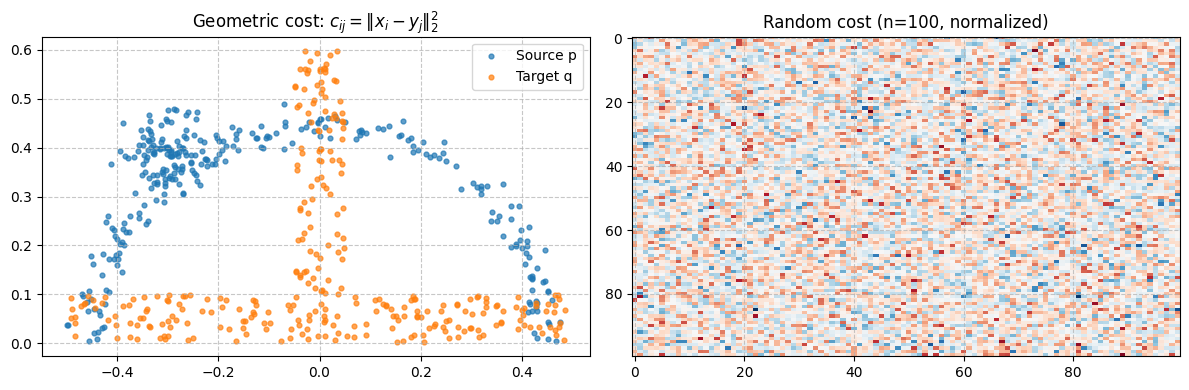

In [30]:
def make_geometric_problem(n=300, seed=42):
    """
    Reproduction exacte de la Figure 4 du papier Chizat (2024).
    Source (p) : Amas dense en haut à gauche + arche (demi-cercle).
    Target (q) : Barre verticale + barre horizontale en bas (T inversé).
    """
    key = jax.random.PRNGKey(seed)
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)

    # --- Source (Bleu) : Cluster + Arche ---
    # 1. Cluster vers le centre gauche (autour de x=-0.3, y=0.4)
    cluster_source = jax.random.normal(k1, (100, 2)) * 0.04 + jnp.array([-0.3, 0.4])
    
    # 2. Arche (demi-cercle avec un rayon d'environ 0.45 + un peu de bruit)
    angles = jax.random.uniform(k2, (200,), minval=0.0, maxval=jnp.pi)
    radii = 0.45 + jax.random.normal(k3, (200,)) * 0.02
    arc_x = radii * jnp.cos(angles)
    arc_y = radii * jnp.sin(angles)
    arc_source = jnp.stack([arc_x, arc_y], axis=1)
    
    x = jnp.vstack([cluster_source, arc_source])

    # --- Target (Orange) : T inversé ---
    # 1. Barre verticale au centre
    bar_v = jax.random.uniform(k4, (100, 2), minval=jnp.array([-0.05, 0.1]), maxval=jnp.array([0.05, 0.6]))
    # 2. Barre horizontale en bas
    bar_h = jax.random.uniform(k5, (200, 2), minval=jnp.array([-0.5, 0.0]), maxval=jnp.array([0.5, 0.1]))
    
    y = jnp.vstack([bar_v, bar_h])

    # Marginales uniformes (p = 1/m, q = 1/n)
    p = jnp.ones(n) / n
    q = jnp.ones(n) / n

    # Matrice de coût géométrique au carré normalisée par son oscillation
    geom = pointcloud.PointCloud(x, y, cost_fn=costs.SqEuclidean())
    C = geom.cost_matrix
    C = C / (jnp.max(C) - jnp.min(C))
    
    return x, y, p, q, C


def make_random_problem(n=100, seed=0):
    """Random cost matrix with random marginals (App. A)."""
    key = jax.random.PRNGKey(seed)
    k1, k2, k3 = jax.random.split(key, 3)
    C = jax.random.normal(k1, (n, n))
    C = C / (jnp.max(C) - jnp.min(C))
    p = jax.random.uniform(k2, (n,)); p = p / p.sum()
    q = jax.random.uniform(k3, (n,)); q = q / q.sum()
    return p, q, C


x, y, p_geo, q_geo, C_geo = make_geometric_problem()
p_rnd, q_rnd, C_rnd = make_random_problem()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x[:, 0], x[:, 1], s=12, alpha=0.7, label='Source p')
axes[0].scatter(y[:, 0], y[:, 1], s=12, alpha=0.7, label='Target q')
axes[0].set_title(r'Geometric cost: $c_{ij}=\|x_i-y_j\|_2^2$')
axes[0].legend()
axes[1].imshow(np.array(C_rnd), cmap='RdBu_r', aspect='auto')
axes[1].set_title('Random cost (n=100, normalized)')
plt.tight_layout(); plt.show()

In [31]:
@jax.jit
def project_transport_plan(pi, p, q):
    """
    Algorithm 2: Projection onto transport plans (Altschuler et al., 2017).

    Maps any non-negative matrix pi to a valid plan pi_bar in Gamma(p, q)
    in O(nm) time. Used to compute OT suboptimality for intermediate iterates.
    Lemma 2.3 guarantees:
        <C, pi_bar> - OT(p,q) <= log(mn)/beta + 4*||pi*1 - p||_1 * ||c||_osc
    """
    # Step (a): rescale rows
    a = jnp.minimum(1.0, p / (pi.sum(axis=1) + 1e-300))
    pi2 = a[:, None] * pi
    # Step (b): rescale columns
    b = jnp.minimum(1.0, q / (pi2.sum(axis=0) + 1e-300))
    pi3 = pi2 * b[None, :]
    # Step (c): rank-1 correction
    dp = p - pi3.sum(axis=1)
    dq = q - pi3.sum(axis=0)
    return pi3 + jnp.outer(dp, dq) / (jnp.abs(dp).sum() + 1e-300)


def projected_cost(pi, C, p, q):
    return jnp.sum(project_transport_plan(pi, p, q) * C)

### Sanity check: Algorithm 2
We verify that any matrix projected via Algorithm 2 exactly satisfies both
marginal constraints.

In [32]:
pi_rand = jax.random.uniform(jax.random.PRNGKey(99), C_geo.shape)
pi_proj = project_transport_plan(pi_rand, p_geo, q_geo)

row_err = float(jnp.max(jnp.abs(pi_proj.sum(axis=1) - p_geo)))
col_err = float(jnp.max(jnp.abs(pi_proj.sum(axis=0) - q_geo)))
print(f"Max row error after projection: {row_err:.2e}  (should be ~0)")
print(f"Max col error after projection: {col_err:.2e}  (should be ~0)")
assert row_err < 1e-10 and col_err < 1e-10
print("✓ Algorithm 2 correct.")

Max row error after projection: 1.73e-18  (should be ~0)
Max col error after projection: 1.30e-18  (should be ~0)
✓ Algorithm 2 correct.


## **III — Standard Sinkhorn: Speed-Accuracy Pareto Front**

Standard Sinkhorn at fixed β converges to EOT_β(p,q), which is O(β⁻¹) away
from OT(p,q). The **Pareto front** (Fig. 1, dashed curves) is the pointwise
minimum over all fixed-β runs. Beating it with a single run is the goal of
annealing.

We implement Algorithm 1 in log-domain, carrying log_a = log(a) and
log_b = log(b). The critical detail from the paper: the row update uses
K_{t-1} = exp(−C/ε_{t-1}) and the col update uses K_t = exp(−C/ε_t).
Standard Sinkhorn is the special case of a constant schedule.

In [33]:
@jax.jit
def run_annealed_sinkhorn(C, p, q, epsilons):
    """
    Algorithm 1: Annealed Sinkhorn (log-domain, JAX-compiled).

    Implements the exact update sequence from the paper:
        a_t = p  / (K_{t-1} b_{t-1})   [row proj on eps_prev]
        K_t = exp(-C / eps_t)           [temperature update]
        b_t = q  / (K_t^T a_t)         [col proj on eps]

    Works for both standard Sinkhorn (constant epsilons)
    and annealed variants (decreasing epsilons).

    Args:
        C:       (m, n) cost matrix normalized to unit oscillation.
        p, q:    marginals.
        epsilons: (T,) sequence of regularization parameters.

    Returns:
        costs: (T,) projected OT cost <C, proj(pi_t)> at each iteration.
    """
    log_a = jnp.zeros_like(p)
    log_b = jnp.zeros_like(q)
    eps_prev_seq = jnp.concatenate([epsilons[:1], epsilons[:-1]])

    def body(carry, params):
        log_a, log_b = carry
        eps_prev, eps = params
        log_a = jnp.log(p) - jax.scipy.special.logsumexp(
            -C / eps_prev + log_b[None, :], axis=1)
        log_b = jnp.log(q) - jax.scipy.special.logsumexp(
            -C / eps + log_a[:, None], axis=0)
        pi = jnp.exp(log_a[:, None] + log_b[None, :] - C / eps)
        return (log_a, log_b), projected_cost(pi, C, p, q)

    _, costs_out = jax.lax.scan(body, (log_a, log_b), (eps_prev_seq, epsilons))
    return costs_out

In [34]:
# --- OT reference value via OTT-JAX Sinkhorn solver ---
# We use ott.solvers.linear.Sinkhorn at very small epsilon for a tight reference.
def compute_ot_ref_ottjax(C, p, q, epsilon=1e-6):
    """Compute OT(p,q) using OTT-JAX's Sinkhorn solver."""
    from ott.geometry.geometry import Geometry
    geom = Geometry(cost_matrix=C, epsilon=1e-6)
    prob = linear_problem.LinearProblem(geom, a=p, b=q)
    solver = sinkhorn.Sinkhorn(max_iterations=50000, threshold=1e-12)
    out = solver(prob)
    return float(jnp.sum(out.matrix * C))

print("Computing OT references via OTT-JAX Sinkhorn...")
OT_geo = compute_ot_ref_ottjax(C_geo, p_geo, q_geo)
OT_rnd = compute_ot_ref_ottjax(C_rnd, p_rnd, q_rnd)
print(f"OT(p,q) geometric: {OT_geo:.6f}")
print(f"OT(p,q) random:    {OT_rnd:.6f}")

# --- Pareto front: standard Sinkhorn at multiple fixed β ---
T = 1000
iterations = jnp.arange(1, T + 1)
beta_values = [10, 50, 100, 200, 500, 1000, 2000, 5000]

def compute_pareto(C, p, q, ot_ref, T=1000):
    curves = {}
    for beta in beta_values:
        raw = run_annealed_sinkhorn(C, p, q, jnp.full(T, 1.0 / beta))
        curves[beta] = np.maximum(np.array(raw) - ot_ref, 1e-10)
    front = np.min(np.stack(list(curves.values())), axis=0)
    return curves, front

print("Computing Pareto fronts...")
pareto_geo, front_geo = compute_pareto(C_geo, p_geo, q_geo, OT_geo)
pareto_rnd, front_rnd = compute_pareto(C_rnd, p_rnd, q_rnd, OT_rnd)
print("Done.")

Computing OT references via OTT-JAX Sinkhorn...
OT(p,q) geometric: 0.068823
OT(p,q) random:    -0.305943
Computing Pareto fronts...
Done.


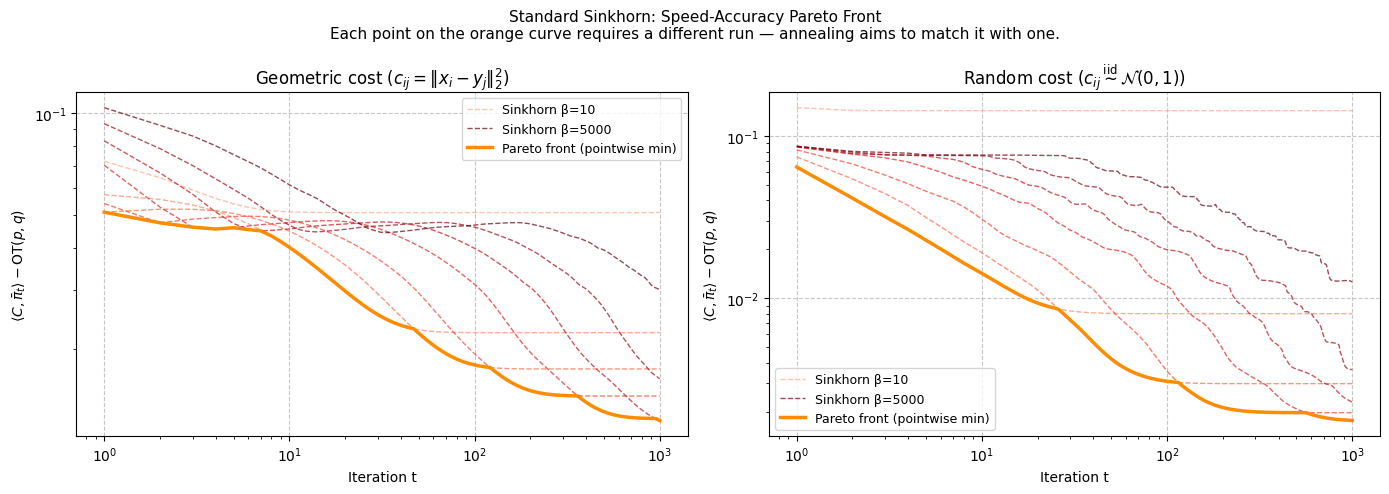

In [35]:
# --- Plot: Pareto front only ---
# Before introducing annealing, we visualize what we are trying to beat:
# each dashed curve is one run of standard Sinkhorn at fixed β.
# The orange curve is the pointwise minimum — no single run achieves it.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pareto_curves, front, ot_ref, title in [
    (axes[0], pareto_geo, front_geo, OT_geo,
     r'Geometric cost ($c_{ij}=\|x_i-y_j\|_2^2$)'),
    (axes[1], pareto_rnd, front_rnd, OT_rnd,
     r'Random cost ($c_{ij}\overset{\rm iid}{\sim}\mathcal{N}(0,1)$)'),
]:
    cmap = plt.cm.Reds
    iters = np.arange(1, T + 1)
    for i, (beta, curve) in enumerate(pareto_curves.items()):
        col = cmap(0.3 + 0.7 * i / (len(pareto_curves) - 1))
        ax.loglog(iters, curve, '--', color=col, lw=1.0, alpha=0.7,
                  label=f'Sinkhorn β={beta}' if beta in [10, 5000] else '_')
    ax.loglog(iters, front, color='darkorange', lw=2.5,
              label='Pareto front (pointwise min)')
    ax.set_xlabel('Iteration t')
    ax.set_ylabel(r'$\langle C,\bar\pi_t\rangle - \mathrm{OT}(p,q)$')
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle('Standard Sinkhorn: Speed-Accuracy Pareto Front\n'
             'Each point on the orange curve requires a different run — '
             'annealing aims to match it with one.', fontsize=11)
plt.tight_layout()
plt.show()

## **III bis — OTT-JAX's Default Schedule and its Limitation**

OTT-JAX provides `ott.geometry.epsilon_scheduler.Epsilon` for annealing:

```python
Epsilon(target, init=1.0, decay=1.0)
# epsilon_t = target + (init - target) * decay^t
```

This implements an **exponential decay** schedule, which is the default in
OTT-JAX and most OT libraries. However, Theorem 2.1 of the paper shows that
convergence to OT requires **both**:
- β_t → +∞  (ε_t → 0)   ← exponential satisfies this
- α_t = β_t − β_{t-1} → 0  ← **exponential violates this**

For an exponential schedule ε_t = ε_0 · γ^t (γ < 1):
    β_t = β_0 · (1/γ)^t   grows exponentially
    α_t = β_t − β_{t-1} = β_0 (1/γ)^{t-1}(1/γ − 1)  → +∞

α_t diverges — this is a direct violation of Theorem 2.1's necessary condition
α_t → 0. The relaxation error O(α_t) therefore grows without bound,
which is why exponential schedules are unsuitable for solving OT.

/var/folders/f0/klngflt94f5c3jj4c40wzgrc0000gn/T/ipykernel_23641/2582783611.py:23: RuntimeWarning: divide by zero encountered in divide
  betas_exp  = 1.0 / np.array(eps_exp)


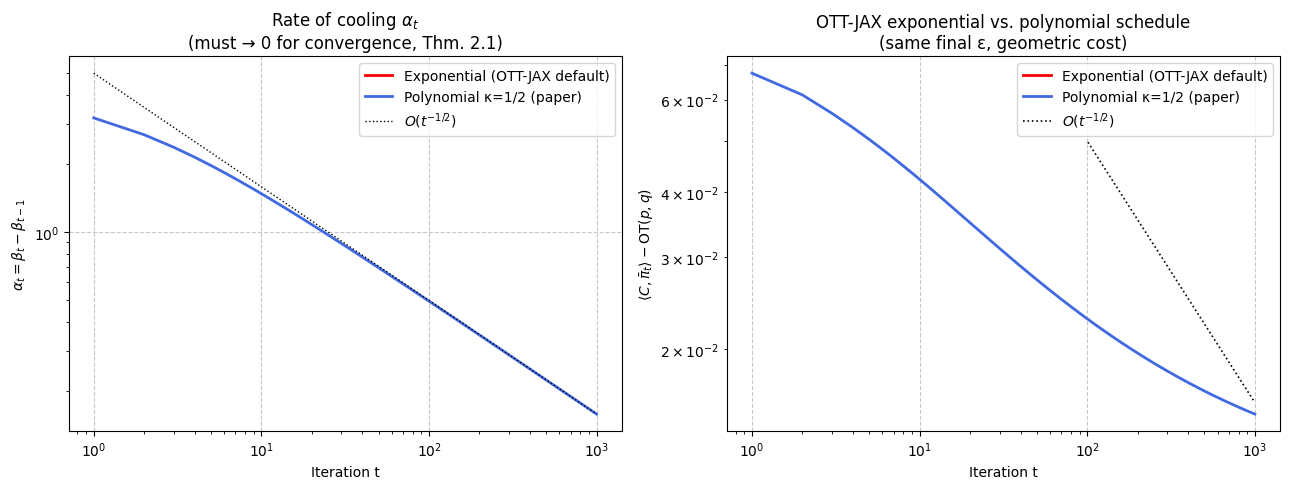

Note: the exponential schedule converges faster initially but
accumulates relaxation error O(alpha_t) that prevents it from
tracking the optimal regularization path (Theorem 3.2).


In [36]:
beta_0 = 10.0
eps_0  = 1.0 / beta_0

# --- OTT-JAX default: exponential schedule ---
# We match the same final epsilon as the polynomial κ=1/2 schedule at T=1000
# Compute decay so that scheduler(T-1) = eps_final_poly exactly
eps_final_poly = eps_0 / (1 + T) ** 0.5
decay = ((eps_final_poly - eps_0 * 0) / (eps_0 - 0)) ** (1.0 / (T - 1))
# Simpler: just set target=0, init=eps_0, solve decay^(T-1) = eps_final_poly/eps_0
scheduler_exp = Epsilon(target=0.0, init=eps_0, decay=decay)
eps_exp = jnp.array([float(scheduler_exp(t)) for t in range(T)])
# --- Paper's polynomial schedule κ=1/2 ---
eps_poly_half = eps_0 / (1 + iterations) ** 0.5
eps_poly_23   = eps_0 / (1 + iterations) ** (2/3)

# Run both on geometric problem
costs_exp  = np.maximum(np.array(run_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_exp))
                        - OT_geo, 1e-10)
costs_half = np.maximum(np.array(run_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_poly_half))
                        - OT_geo, 1e-10)

# Show alpha_t = beta_t - beta_{t-1} for each schedule
betas_exp  = 1.0 / np.array(eps_exp)
betas_poly = 1.0 / np.array(eps_poly_half)
alphas_exp  = np.diff(betas_exp)
alphas_poly = np.diff(betas_poly)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(np.arange(1, T), alphas_exp,  color='red',       lw=2, label='Exponential (OTT-JAX default)')
ax.loglog(np.arange(1, T), alphas_poly, color='royalblue', lw=2, label='Polynomial κ=1/2 (paper)')
ax.loglog(np.arange(1, T), 5 * np.arange(1, T)**(-0.5), 'k:', lw=1, label=r'$O(t^{-1/2})$')
ax.set_xlabel('Iteration t')
ax.set_ylabel(r'$\alpha_t = \beta_t - \beta_{t-1}$')
ax.set_title(r'Rate of cooling $\alpha_t$'
             '\n(must → 0 for convergence, Thm. 2.1)')
ax.legend()

ax = axes[1]
ax.loglog(np.arange(1, T+1), costs_exp,  color='red',       lw=2,
          label='Exponential (OTT-JAX default)')
ax.loglog(np.arange(1, T+1), costs_half, color='royalblue', lw=2,
          label='Polynomial κ=1/2 (paper)')
ax.loglog(np.arange(101, T+1), 0.5 * np.arange(101, T+1)**(-0.5),
          'k:', lw=1.2, label=r'$O(t^{-1/2})$')
ax.set_xlabel('Iteration t')
ax.set_ylabel(r'$\langle C, \bar\pi_t\rangle - \mathrm{OT}(p,q)$')
ax.set_title('OTT-JAX exponential vs. polynomial schedule\n'
             '(same final ε, geometric cost)')
ax.legend()

plt.tight_layout()
plt.show()

print("Note: the exponential schedule converges faster initially but")
print("accumulates relaxation error O(alpha_t) that prevents it from")
print("tracking the optimal regularization path (Theorem 3.2).")

## **IV — Figure 2a: What is the Optimal κ?**

Theorem 3.2 predicts two competing error terms for the regularization path
with a polynomial schedule β_t = β₀(1+t)^κ:

$$\langle c, \bar\pi_t\rangle - \mathrm{OT}(p,q) \leq
\underbrace{O(t^{-\kappa})}_{\text{entropic error}}
+ \underbrace{O(t^{\kappa-1})}_{\text{relaxation error}}$$

Balancing both terms: −κ = κ − 1  →  **κ = 1/2**, giving rate O(t^{−1/2}).

We verify this by sweeping κ ∈ (0,1) and measuring suboptimality at t = 200.

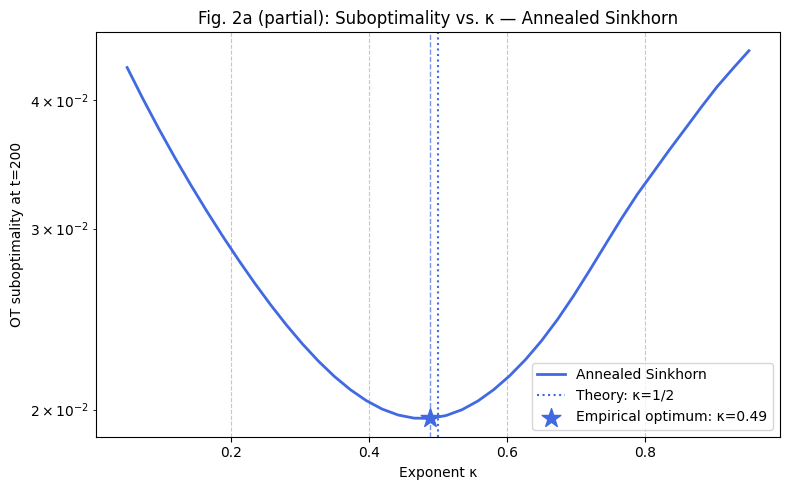

Empirical optimal κ = 0.49  (theory: 0.50)


In [37]:
T_sweep = 200
iters_sweep = jnp.arange(1, T_sweep + 1, dtype=float)
kappas = np.linspace(0.05, 0.95, 40)

subopt_annealed = []
for kappa in kappas:
    eps_k = eps_0 / (1 + iters_sweep) ** float(kappa)
    c = run_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_k)
    subopt_annealed.append(float(c[-1]) - OT_geo)
subopt_annealed = np.array(subopt_annealed)

kopt_ann = kappas[np.argmin(np.abs(subopt_annealed))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(kappas, np.abs(subopt_annealed), color='royalblue', lw=2,
            label='Annealed Sinkhorn')
ax.axvline(0.5,     color='royalblue', ls=':',  lw=1.5, label='Theory: κ=1/2')
ax.axvline(kopt_ann, color='royalblue', ls='--', lw=1.0, alpha=0.7)
ax.scatter([kopt_ann], [np.abs(subopt_annealed).min()],
           marker='*', s=200, color='royalblue', zorder=5,
           label=f'Empirical optimum: κ={kopt_ann:.2f}')
ax.set_xlabel('Exponent κ')
ax.set_ylabel('OT suboptimality at t=200')
ax.set_title(r'Fig. 2a (partial): Suboptimality vs. κ — Annealed Sinkhorn')
ax.legend()
plt.tight_layout(); plt.show()
print(f"Empirical optimal κ = {kopt_ann:.2f}  (theory: 0.50)")

## **V — Debiased Annealed Sinkhorn (Algorithm 3)**

The relaxation error O(α_t) comes from each temperature jump shifting the
effective first marginal away from p. Proposition 4.1 shows this can be
cancelled by replacing p with:

$$\tilde{p}_t = a_{t-1}^{\,\rho_t} \odot p, \qquad
\rho_t = 1 - \frac{\beta_{t-2}}{\beta_{t-1}} = 1 - \frac{\varepsilon_{t-1}}{\varepsilon_{t-2}}$$

In log-domain (Algorithm 3), the row update becomes:

$$\log a_t = \rho_t \cdot \log a_{t-1} + \log p - \log(K_{t-1} b_{t-1})$$

When ρ_t = 0 (constant β) this reduces to standard Sinkhorn.
With the O(α_t) relaxation error cancelled, a faster schedule κ = 2/3
becomes optimal, achieving O(t^{-2/3}) — breaking the universal O(t^{-1/2})
bottleneck of standard Annealed Sinkhorn.

Running algorithms on geometric cost...


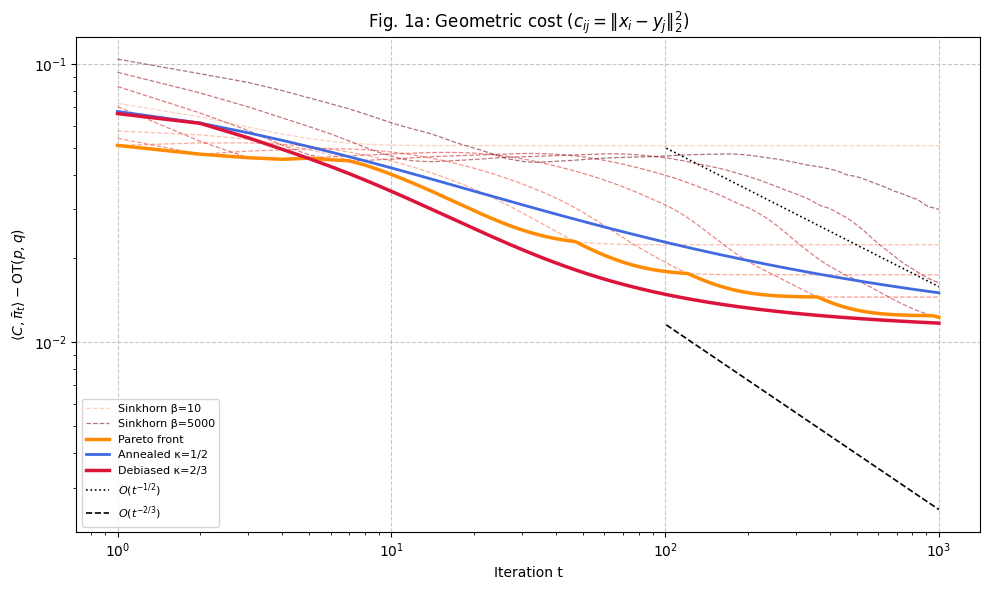

In [38]:
@jax.jit
def run_debiased_annealed_sinkhorn(C, p, q, epsilons):
    """
    Algorithm 3: Debiased Annealed Sinkhorn (log-domain, JAX-compiled).

    Debiased row update (Prop. 4.1):
        log_a_t = rho_t * log_a_{t-1} + log(p) - log(K_{t-1} b_{t-1})
    where rho_t = 1 - eps_{t-1}/eps_{t-2}  (= 1 - beta_{t-2}/beta_{t-1}).

    rho_t = 0 at t=0 (no debiasing on first step).
    Col update is identical to standard Annealed Sinkhorn.
    """
    log_a = jnp.zeros_like(p)
    log_b = jnp.zeros_like(q)
    eps_prev = jnp.concatenate([epsilons[:1], epsilons[:-1]])   # eps_{t-1}
    eps_pp   = jnp.concatenate([epsilons[:1], eps_prev[:-1]])   # eps_{t-2}
    rhos = 1.0 - eps_prev / eps_pp

    def body(carry, params):
        log_a, log_b = carry
        ep, e, rho = params
        log_a = rho * log_a + jnp.log(p) - jax.scipy.special.logsumexp(
            -C / ep + log_b[None, :], axis=1)
        log_b = jnp.log(q) - jax.scipy.special.logsumexp(
            -C / e + log_a[:, None], axis=0)
        pi = jnp.exp(log_a[:, None] + log_b[None, :] - C / e)
        return (log_a, log_b), projected_cost(pi, C, p, q)

    _, costs_out = jax.lax.scan(body, (log_a, log_b), (eps_prev, epsilons, rhos))
    return costs_out


# --- Run all algorithms (geometric) ---
print("Running algorithms on geometric cost...")
costs_ann_geo = np.maximum(
    np.array(run_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_poly_half)) - OT_geo, 1e-10)
costs_deb_geo = np.maximum(
    np.array(run_debiased_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_poly_23)) - OT_geo, 1e-10)

# --- Figure 1a: geometric cost ---
def plot_fig1(ax, pareto_curves, front, costs_ann, costs_deb, title):
    cmap = plt.cm.Reds
    iters = np.arange(1, len(front) + 1)
    for i, (beta, curve) in enumerate(pareto_curves.items()):
        col = cmap(0.3 + 0.7 * i / (len(pareto_curves) - 1))
        ax.loglog(iters, curve, '--', color=col, lw=0.9, alpha=0.55,
                  label=f'Sinkhorn β={beta}' if beta in [10, 5000] else '_')
    ax.loglog(iters, front,      color='darkorange', lw=2.5, label='Pareto front')
    ax.loglog(iters, costs_ann,  color='royalblue',  lw=2.0, label='Annealed κ=1/2')
    ax.loglog(iters, costs_deb,  color='crimson',    lw=2.5, label='Debiased κ=2/3')
    t_s = iters[100:]
    ax.loglog(t_s, 0.5  * t_s**(-0.5), 'k:',  lw=1.2, label=r'$O(t^{-1/2})$')
    ax.loglog(t_s, 0.25 * t_s**(-2/3), 'k--', lw=1.2, label=r'$O(t^{-2/3})$')
    ax.set_xlabel('Iteration t')
    ax.set_ylabel(r'$\langle C,\bar\pi_t\rangle - \mathrm{OT}(p,q)$')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, ax = plt.subplots(figsize=(10, 6))
plot_fig1(ax, pareto_geo, front_geo, costs_ann_geo, costs_deb_geo,
          r'Fig. 1a: Geometric cost ($c_{ij}=\|x_i-y_j\|_2^2$)')
plt.tight_layout(); plt.show()

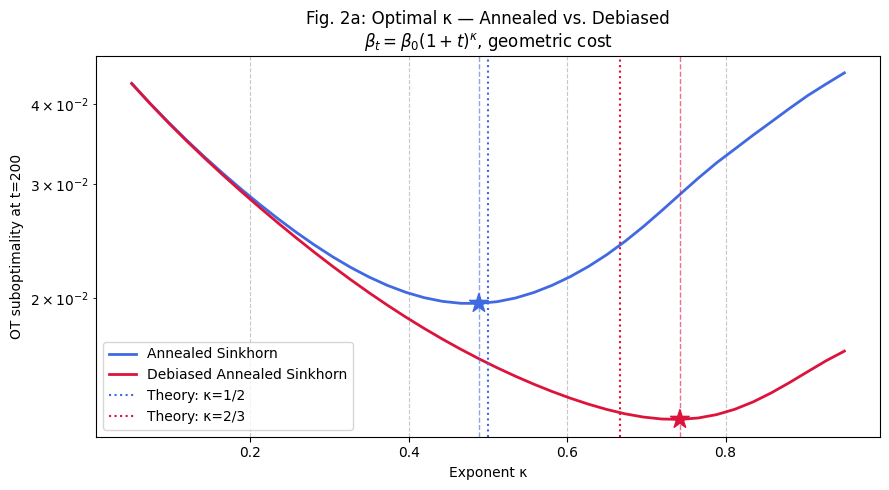

Optimal κ — Annealed:  0.49  (theory: 0.50)
Optimal κ — Debiased:  0.74  (theory: 0.67)


In [39]:
subopt_debiased = []
for kappa in kappas:
    eps_k = eps_0 / (1 + iters_sweep) ** float(kappa)
    c = run_debiased_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_k)
    subopt_debiased.append(float(c[-1]) - OT_geo)
subopt_debiased = np.array(subopt_debiased)

kopt_deb = kappas[np.argmin(np.abs(subopt_debiased))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(kappas, np.abs(subopt_annealed), color='royalblue', lw=2,
            label='Annealed Sinkhorn')
ax.semilogy(kappas, np.abs(subopt_debiased), color='crimson',   lw=2,
            label='Debiased Annealed Sinkhorn')
ax.axvline(0.5,      color='royalblue', ls=':', lw=1.5, label='Theory: κ=1/2')
ax.axvline(2/3,      color='crimson',   ls=':', lw=1.5, label='Theory: κ=2/3')
ax.axvline(kopt_ann, color='royalblue', ls='--', lw=1, alpha=0.6)
ax.axvline(kopt_deb, color='crimson',   ls='--', lw=1, alpha=0.6)
ax.scatter([kopt_ann, kopt_deb],
           [np.abs(subopt_annealed).min(), np.abs(subopt_debiased).min()],
           marker='*', s=200, zorder=5, color=['royalblue', 'crimson'])
ax.set_xlabel('Exponent κ')
ax.set_ylabel('OT suboptimality at t=200')
ax.set_title('Fig. 2a: Optimal κ — Annealed vs. Debiased\n'
             r'$\beta_t = \beta_0(1+t)^\kappa$, geometric cost')
ax.legend()
plt.tight_layout(); plt.show()
print(f"Optimal κ — Annealed:  {kopt_ann:.2f}  (theory: 0.50)")
print(f"Optimal κ — Debiased:  {kopt_deb:.2f}  (theory: 0.67)")

## **VI — Figure 1b: Random Cost**

The paper compares geometric and random cost settings (Fig. 1). In the
geometric case, the multiscale structure of the problem means annealing
can exploit warm-starting effectively. In the random case, this structure
is absent and the benefit of annealing is smaller — though Debiased
Annealed Sinkhorn still approaches the Pareto front.

Running algorithms on random cost...


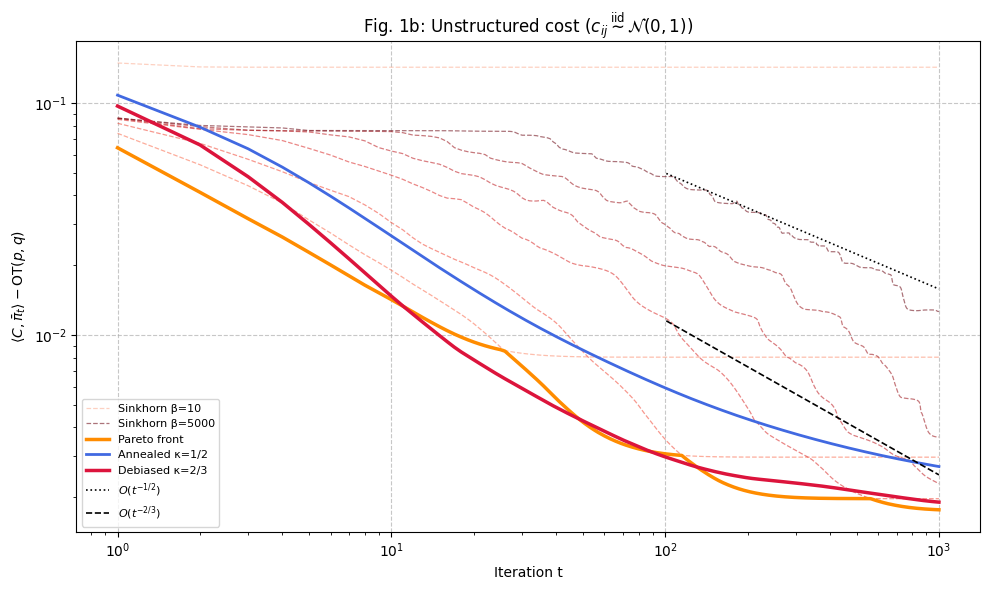

In [40]:
print("Running algorithms on random cost...")
costs_ann_rnd = np.maximum(
    np.array(run_annealed_sinkhorn(C_rnd, p_rnd, q_rnd, eps_poly_half[:T])) - OT_rnd, 1e-10)
costs_deb_rnd = np.maximum(
    np.array(run_debiased_annealed_sinkhorn(C_rnd, p_rnd, q_rnd, eps_poly_23[:T])) - OT_rnd, 1e-10)

fig, ax = plt.subplots(figsize=(10, 6))
plot_fig1(ax, pareto_rnd, front_rnd, costs_ann_rnd, costs_deb_rnd,
          r'Fig. 1b: Unstructured cost ($c_{ij} \overset{\rm iid}{\sim} \mathcal{N}(0,1)$)')
plt.tight_layout(); plt.show()

## **VI bis — Figure 3a: Piecewise Constant Schedules**

A natural alternative to Debiased Annealed Sinkhorn for reducing the
relaxation error is to use a **piecewise constant schedule**: hold β_t
constant for a while (plateau), letting the relaxation error decay, then
jump to the next temperature.

Following App. A of the paper, we use the base schedule
β̄_t = β₀(1+t)^κ but only update β_t = β̄_t at times t = 16k², k ∈ ℕ,
giving plateaus of increasing length 16, 64, 144, 256, …

The paper's prediction: this technique reduces the error *at the end of
each plateau*, but the peaks at each temperature jump still follow
Θ(t^{κ−1}), so the long-run rate remains O(t^{−1/2}) — it cannot beat
Debiased Annealed Sinkhorn.

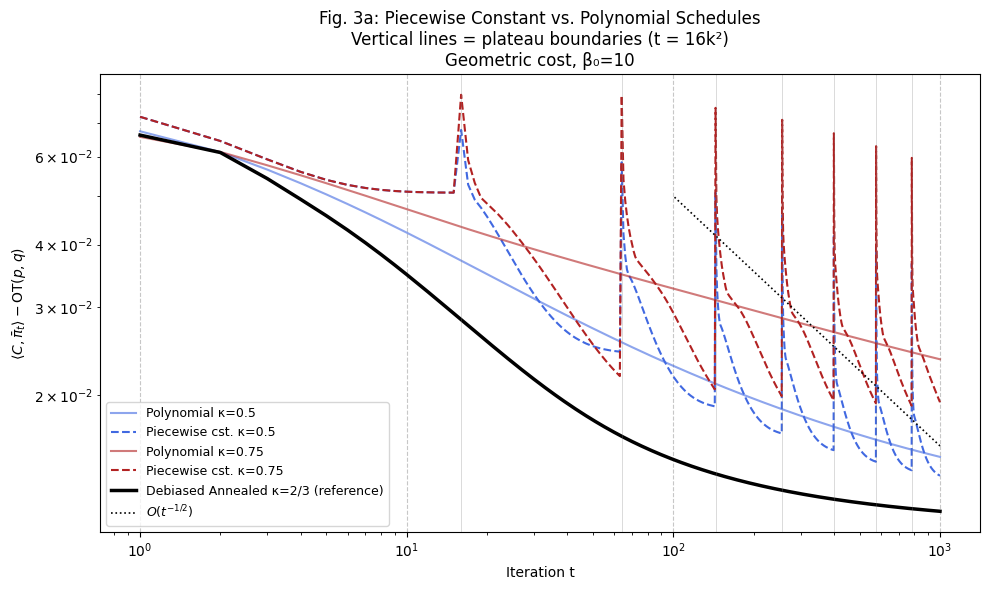

Observation: piecewise constant schedules improve at each plateau end,
but the envelope of peaks still follows O(t^{-1/2}) — same asymptotic
rate as continuous polynomial. Debiased Annealed Sinkhorn outperforms both.


In [41]:
def make_piecewise_schedule(beta_0, kappa, T):
    """
    Piecewise constant annealing schedule (App. A).
    Base schedule: beta_bar_t = beta_0*(1+t)^kappa.
    Update only at times t = 16*k^2 (k=1,2,...), holding constant otherwise.
    Plateau lengths: 16, 64-16=48, 144-64=80, 256-144=112, ...
    """
    iters = np.arange(1, T + 1)
    base_betas = beta_0 * (1 + iters) ** kappa

    update_times = set()
    k = 1
    while 16 * k**2 <= T:
        update_times.add(16 * k**2)
        k += 1

    betas_pc = np.zeros(T)
    current = beta_0
    for t in range(1, T + 1):
        if t in update_times:
            current = float(base_betas[t - 1])
        betas_pc[t - 1] = current

    return jnp.array(1.0 / betas_pc)   # return epsilons


iters_f3 = np.arange(1, T + 1)
kappa_list = [0.5, 0.75]
colors = {0.5: 'royalblue', 0.75: 'firebrick'}

fig, ax = plt.subplots(figsize=(10, 6))

for kappa in kappa_list:
    col = colors[kappa]

    # Continuous polynomial
    eps_poly = eps_0 / (1 + jnp.arange(1, T + 1, dtype=float)) ** kappa
    costs_poly = np.maximum(
        np.array(run_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_poly)) - OT_geo, 1e-10)

    # Piecewise constant
    eps_pc = make_piecewise_schedule(beta_0, kappa, T)
    costs_pc = np.maximum(
        np.array(run_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_pc)) - OT_geo, 1e-10)

    ax.loglog(iters_f3, costs_poly, '-',  color=col, lw=1.5, alpha=0.6,
              label=f'Polynomial κ={kappa}')
    ax.loglog(iters_f3, costs_pc,   '--', color=col, lw=1.5,
              label=f'Piecewise cst. κ={kappa}')

# Debiased κ=2/3 as reference
costs_deb_ref = np.maximum(
    np.array(run_debiased_annealed_sinkhorn(C_geo, p_geo, q_geo, eps_poly_23)) - OT_geo, 1e-10)
ax.loglog(iters_f3, costs_deb_ref, 'k-', lw=2.5,
          label='Debiased Annealed κ=2/3 (reference)')

# Slope references
t_s = iters_f3[100:]
ax.loglog(t_s, 0.5 * t_s ** (-0.5), 'k:', lw=1.2, label=r'$O(t^{-1/2})$')

# Mark plateau boundaries
k = 1
while 16 * k**2 <= T:
    ax.axvline(16 * k**2, color='gray', lw=0.5, alpha=0.4)
    k += 1

ax.set_xlabel('Iteration t')
ax.set_ylabel(r'$\langle C,\bar\pi_t\rangle - \mathrm{OT}(p,q)$')
ax.set_title('Fig. 3a: Piecewise Constant vs. Polynomial Schedules\n'
             'Vertical lines = plateau boundaries (t = 16k²)\n'
             'Geometric cost, β₀=10')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Observation: piecewise constant schedules improve at each plateau end,")
print("but the envelope of peaks still follows O(t^{-1/2}) — same asymptotic")
print("rate as continuous polynomial. Debiased Annealed Sinkhorn outperforms both.")

## **VII — Conclusion**

This notebook reproduces the main results of Chizat (2024):

| Algorithm | Optimal schedule | Predicted rate | Observed |
|---|---|---|---|
| Annealed Sinkhorn | κ = 1/2 | O(t⁻¹/²) | ✓ Fig. 2a |
| Debiased Annealed Sinkhorn | κ = 2/3 | O(t⁻²/³) | ✓ Fig. 2a |

**Three key takeaways:**

1. **OTT-JAX's `Epsilon` scheduler (exponential) is theoretically suboptimal.**
   It violates α_t → 0 (Theorem 2.1) and accumulates relaxation error that
   cannot be traded off against the entropic error. The convergence condition
   requires β_t → +∞ *and* β_t − β_{t-1} → 0.

2. **The O(t⁻¹/²) bottleneck is a universal limitation of Annealed Sinkhorn.**
   No concave schedule can achieve a better rate (Theorem 3.2). The optimal
   schedule is β_t = Θ(√t), verified empirically in Fig. 2a.

3. **Debiased Annealed Sinkhorn (Algorithm 3) breaks this ceiling.** With
   negligible extra cost (one elementwise multiply per iteration), it cancels
   the first-order relaxation error, unlocks κ = 2/3 and O(t⁻²/³), and
   approaches or beats the entire Pareto front in a single run (Fig. 1).

**Connection to OTT-JAX.** A natural extension of this work would be to
integrate polynomial schedules and the debiasing correction natively into
OTT-JAX's `Epsilon` class and `Sinkhorn` solver, making them available to
all users of the toolbox.

### References
- Chizat, L. (2024). *Annealed Sinkhorn for Optimal Transport.* arXiv:2408.11620.
- Altschuler, J., Niles-Weed, J., Rigollet, P. (2017). *Near-linear time
  approximation algorithms for optimal transport via Sinkhorn iteration.* NeurIPS.
- Cuturi, M. et al. (2022). *OTT-JAX: A JAX Toolbox for All Things Wasserstein.*
  arXiv:2201.12324.